# 17 — Full-Stack Smoke Test (post-NB15 features)

End-to-end smoke test that exercises every feature added since NB15 and times every block so we can spot the bottleneck before scaling up to the headline run.

**Features under test (added since NB15):**
1. Package communication mode — single broadcast / single peer pass per phase covers all six policies.
2. Day-0 anchor: `ground_truth_with_rationale` — Day 0 opinion seeded from the YouGov response and rationalised by the LLM.
3. Day-1+ rationale memory injection — `assemble_context()` surfaces the Day-0 rationale (no numeric "Day 0: C, Day 1: E" trajectory).
4. Debias on end-of-day surveys (Condition B, anti-sycophancy + two-step elicitation).
5. Extended-thinking survey model.
6. Dual-model run — `gpt-4o-mini` for messaging, `claude-sonnet-4-6` for surveys.

**Reference baseline (NB17 prior run, same config):** 5 agents × 2 days, ~30 min wall-time, ~£1.20 cost. Use the timing summary at the bottom to identify the dominant block before optimising.

**N=5 caveat.** With `p_intra=0.15` / `p_inter=0.02`, expected degree per agent ≈ 0.3, so most agents have **zero neighbours** and Phase C silently no-ops. Section 2 prints the network density so this is visible. Peer messaging will fire properly at N≥30.



In [1]:
import os, sys, random, logging, time
from contextlib import contextmanager

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING)

from cag.io.survey import load
from cag.abm.agent import SurveyedCitizen
from cag.abm.environment import SurveyedNation
from cag.abm.attributes.opinion import (
    ALL_CLIMATE_POLICIES,
    ClimatePolicyID,
    PACKAGE_SCOPE,
    PRO_CLIMATE_INDEX_COLUMN,
    SURVEY_QUESTIONS,
)
from cag.abm.sim import (
    run_simulation,
    save_results,
    save_result_plots,
    collect_ground_truth,
    collect_package_ground_truth,
)

from gabm.abm.attributes.gender import GenderMap, GenderID
from gabm.abm.attributes.politics import PoliticsID
from gabm.abm.democracy.election import ElectionID
from cag.abm.attributes.region import UKRegionMap, RegionID
from cag.abm.attributes.education import SurveyEducationMap, EducationID
from cag.abm.attributes.ethnicity import SurveyEthnicityMap, EthnicityID
from cag.abm.attributes.income import SurveyIncomeMap, IncomeID
from cag.abm.attributes.politics import SurveyPoliticsMap
from cag.abm.attributes.family import SurveyFamilyMap, FamilyID
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteMap, UKGE2019VoteID
from cag.abm.democracy.elections.brexit import BrexitVoteMap, BrexitVoteID
from cag.abm.attributes.narratives import (
    SelftranscMap, SelfenhMap, OpennessMap, ConformTradMap, SDOMap, EDOMap, RWAMap,
    rescale_1_6, rescale_1_7,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Timing harness ──────────────────────────────────────────────
TIMINGS = []  # list of (label, seconds)

@contextmanager
def timed(label):
    t0 = time.perf_counter()
    try:
        yield
    finally:
        dt = time.perf_counter() - t0
        TIMINGS.append((label, dt))
        print(f"[TIMER] {label}: {dt:.2f}s")

print("Imports OK")


Imports OK


## 1. Build Sample Nation (5 agents)


In [2]:
N_CITIZENS = 5
RANDOM_SEED = 43
year = 2026
random.seed(RANDOM_SEED)

UKGE2019_ELECTION_ID = ElectionID(0)
BREXIT_REFERENDUM_ID = ElectionID(1)

with timed("build_nation"):
    sn = SurveyedNation(
        year=year, place="UK",
        gender_map=GenderMap(),
        region_map=UKRegionMap(),
        education_map=SurveyEducationMap(),
        ethnicity_map=SurveyEthnicityMap(),
        income_map=SurveyIncomeMap(),
        politics_map=SurveyPoliticsMap(),
        family_map=SurveyFamilyMap(),
        ukge2019_vote_map=UKGE2019VoteMap(UKGE2019_ELECTION_ID),
        brexit_vote_map=BrexitVoteMap(BREXIT_REFERENDUM_ID),
        selftransc_map=SelftranscMap,
        selfenh_map=SelfenhMap,
        openness_map=OpennessMap,
        conformtrad_map=ConformTradMap,
        sdo_map=SDOMap,
        edo_map=EDOMap,
        rwa_map=RWAMap,
    )

    data = load("../data/yougov_survey_data/YouGovProcessedData.csv")
    data = data.sample(n=N_CITIZENS, random_state=RANDOM_SEED).reset_index(drop=True)

    for i in range(len(data)):
        row = data.iloc[i]
        sc = SurveyedCitizen(
            agent_id=row.get('ID', None), environment=sn,
            year_of_birth=year - int(row.get('age', 0)),
            gender_id=GenderID.MALE if int(row.get('male_dummy', 0)) == 1 else GenderID.FEMALE,
            region_id=RegionID(int(row.get('tprofile_GOR', 0))),
            education_id=EducationID(int(row.get('profile_education_level', 0))),
            income_id=IncomeID(int(row.get('tprofile_gross_household', 0))),
            ethnicity_id=EthnicityID(int(row.get('ethnicity_R', 0))),
            family_id=FamilyID.PARENT if int(row.get('parent_dummy', 0)) == 1 else FamilyID.NOT_PARENT,
            ukge2019_vote_id=UKGE2019VoteID(int(row.get('Vote2019R', 0))),
            brexit_vote_id=BrexitVoteID(int(row.get('pastvote_EURef', 0))),
            politics_id=PoliticsID(int(row.get('Political_Left_Right', 0))),
            selftransc_id=rescale_1_6(int(row.get('Selftransc_Val', 0))),
            selfenh_id=rescale_1_6(int(row.get('Selfenh_Values', 0))),
            openness_id=rescale_1_6(int(row.get('Openness', 0))),
            conformtrad_id=rescale_1_6(int(row.get('ConformTrad', 0))),
            sdo_id=rescale_1_7(int(row.get('SDO', 0))),
            edo_id=rescale_1_7(int(row.get('EDO', 0))),
            rwa_id=rescale_1_6(int(row.get('RWA', 0))),
            original_survey_data=data.iloc[i],
        )
        sn.agents_active[sc.id] = sc

print(f"Citizens loaded: {len(sn.agents_active)}")


INFO Columns with NaN counts (before filtering):
tprofile_gross_household    398
Political_Left_Right          6
dtype: int64
INFO Column with most NaNs: tprofile_gross_household (398 NaNs)
INFO 1483 rows after filtering.


[TIMER] build_nation: 0.03s
Citizens loaded: 5


## 2. Network Density Check (N=5 caveat)

Builds the citizen network with the same `p_intra` / `p_inter` we'll use in the simulation, then prints degree statistics. With N=5 the expected degree per agent is ~0.3, so most agents will have **zero neighbours** and Phase C will silently no-op for them. This is the diagnostic for any "0 citizens exchanged messages" warning we see later.



In [3]:
# Reproduce the network the way run_simulation() will build it: exposure → SBM.
# (run_simulation will rebuild this internally; this cell is purely diagnostic.)
P_INTRA, P_INTER = 0.15, 0.02

from cag.abm.agent import PoliticalAgent
sn.political_agent_a = PoliticalAgent("agent_a", "pro_climate")
sn.political_agent_b = PoliticalAgent("agent_b", "anti_climate")

with timed("create_network (diagnostic)"):
    sn.assign_political_exposure()
    sn.create_network(p_intra=P_INTRA, p_inter=P_INTER, seed=RANDOM_SEED)
    sn.assign_network_blocks()

degrees = [len(c.network_neighbors) for c in sn.agents_active.values()]
print(f"Degree per agent: {degrees}")
print(f"Mean degree: {np.mean(degrees):.2f}")
print(f"Agents with 0 neighbours: {sum(1 for d in degrees if d == 0)} / {len(degrees)}")
print(f"Total edges: {sn.network.number_of_edges()}")
if sum(1 for d in degrees if d == 0) > 0:
    print("\nNote: agents with 0 neighbours will be silently skipped in Phase C.\n"
          "This is expected at small N; peer messaging will fire properly at N >= ~30.")


[TIMER] create_network (diagnostic): 0.00s
Degree per agent: [2, 1, 1, 0, 0]
Mean degree: 0.80
Agents with 0 neighbours: 2 / 5
Total edges: 2

Note: agents with 0 neighbours will be silently skipped in Phase C.
This is expected at small N; peer messaging will fire properly at N >= ~30.


## 3. Collect Ground Truth

Per-policy and package-level ground truth captured before the simulation runs, so we can later assert that Day 0 anchored opinions equal these values exactly.



In [4]:
with timed("collect_ground_truth"):
    gt_df = collect_ground_truth(sn.agents_active.values())
    gt_package_df = collect_package_ground_truth(sn.agents_active.values())

print(f"Per-policy GT: {gt_df.shape[0]} rows, {gt_df['policy_id'].nunique()} policies")
print(f"Package GT:    {gt_package_df.shape[0]} rows, mean={gt_package_df['ground_truth'].mean():+.2f}")

print("\nMean GT per policy:")
for pid, grp in gt_df.groupby("policy_id"):
    short = pid.split(".")[-1]
    print(f"  {short:25s}  mean={grp['ground_truth'].mean():+.2f}")

gt_package_df


[TIMER] collect_ground_truth: 0.00s
Per-policy GT: 30 rows, 6 policies
Package GT:    5 rows, mean=+1.33

Mean GT per policy:
  ClimatePolicyID(1)         mean=+1.40
  ClimatePolicyID(2)         mean=+1.00
  ClimatePolicyID(3)         mean=+2.00
  ClimatePolicyID(4)         mean=+1.60
  ClimatePolicyID(5)         mean=+1.40
  ClimatePolicyID(6)         mean=+0.60


,agent_id,index_name,ground_truth
0,1923.0,ProClimatePolSupp,0.666667
1,528.0,ProClimatePolSupp,2.833333
2,541.0,ProClimatePolSupp,2.333333
3,1545.0,ProClimatePolSupp,0.500000
4,1309.0,ProClimatePolSupp,0.333333


## 4. Configure & Run Simulation

Same 5-agent / 2-day / package / debias / thinking / dual-model config as the prior NB17 run, so the wall-time printed below is directly comparable to the **~30 min, ~£1.20** baseline. After this run completes, the per-block timings (Section 9) tell us where to optimise next.

| config key | feature exercised |
|---|---|
| `communication_mode="package"` | Package mode — six policies in one broadcast/peer pass per phase. |
| `day0_anchor="ground_truth_with_rationale"` | GT-anchored Day 0 + LLM rationale. |
| `debias=True` | Two-step anti-sycophancy survey for end-of-day surveys. |
| `thinking=True` | Extended-thinking on the survey model. |
| `survey_model` / `survey_provider` | Dual-model: messaging vs survey LLM independent. |



In [5]:
N_DAYS = 2

config = {
    "n_citizens": N_CITIZENS,
    "communication_mode": "package",
    "package_policies": list(ALL_CLIMATE_POLICIES),
    "day0_anchor": "ground_truth_with_rationale",
    "days": [
        {"phases": ["P-A", "P-B", "C"]},
    ] * N_DAYS,
    "k_peers_per_day": 2,
    "llm_model": "gpt-5-mini",
    "llm_provider": "openai",
    "llm_temperature": 0.5,
    "survey_model": "claude-sonnet-4-6",
    "survey_provider":  "anthropic",
    "thinking": False,
    "debias": True,
    "p_intra": P_INTRA,
    "p_inter": P_INTER,
    "random_seed": RANDOM_SEED,
}

print(f"{N_CITIZENS} agents, {N_DAYS} days, package mode")
print(f"Messaging: {config['llm_model']} ({config['llm_provider']})")
print(f"Surveys:   {config['survey_model']} ({config['survey_provider']}), thinking={config['thinking']}, debias={config['debias']}")
print(f"Day 0 anchor: {config['day0_anchor']}")


5 agents, 2 days, package mode
Messaging: gpt-5-mini (openai)
Surveys:   claude-sonnet-4-6 (anthropic), thinking=False, debias=True
Day 0 anchor: ground_truth_with_rationale


In [6]:
with timed("run_simulation (TOTAL)"):
    results = run_simulation(config, sn)

df_traj = results["opinion_trajectories"]
df_package = results["package_index_trajectories"]
df_ref = results["reflections"]
df_reasoning = results["survey_reasoning"]
df_messages = results["messages"]

print(f"opinion_trajectories: {len(df_traj)} rows")
print(f"package_index_trajectories: {len(df_package)} rows")
print(f"reflections: {len(df_ref)} rows")
print(f"survey_reasoning: {len(df_reasoning)} rows")
print(f"messages: {len(df_messages)} rows")


INFO Simulation: 5 agents, 2 days
INFO Running package baseline survey (day 0), policies=['ClimatePolicyID(1)', 'ClimatePolicyID(2)', 'ClimatePolicyID(3)', 'ClimatePolicyID(4)', 'ClimatePolicyID(5)', 'ClimatePolicyID(6)'], anchor=ground_truth_with_rationale
INFO day0_anchor=ground_truth_with_rationale: debias flag is ignored on Day 0 (still applies to end-of-day surveys).
INFO Day 0 mean package index: +1.33
INFO --- Day 1/2 (package=climate_policy_package, phases=['P-A', 'P-B', 'C']) ---
WARNING OpenAI: model does not support 'temperature', retrying without it
INFO [P-A] Day 1: delivered package message to 5 citizens. Message (first 120 chars): Real Hope, Real Change — for the common good. I strongly support a joined-up climate platform that tackles the cost-of-l...
INFO [P-A] Sample package reflection: - Accelerate roll-out of renewable energy production (more offshore and onshore wind parks, community solar): Slightly support. I like the move toward cleaner power and public-ownershi

[TIMER] run_simulation (TOTAL): 703.32s
opinion_trajectories: 90 rows
package_index_trajectories: 15 rows
reflections: 20 rows
survey_reasoning: 90 rows
messages: 22 rows


## 5. Verify Day-0 Anchor + Day-1 Prompt Content

Two things to check:

1. **Day 0 anchor.** Day-0 opinion equals ground truth exactly for every (agent, policy); one Day-0 rationale stored per (agent, policy) in `survey_reasoning`.
2. **Day-1+ memory injection.** `assemble_context()` for Day 1 must contain the new "Your earlier reasoning on these policies:" block and must **not** contain the old "Your opinion trajectory so far:" block. (This validates the prompt-anchor refactor we just shipped.)



In [7]:
# --- Day-0 anchor checks --------------------------------------------------
day0 = df_traj[df_traj["day"] == 0].copy()
day0["policy_id_str"] = day0["policy_id"].astype(str)
gt = gt_df.copy()
gt["policy_id_str"] = gt["policy_id"].astype(str)
merged = day0.merge(gt, on=["agent_id", "policy_id_str"], how="inner")
assert (merged["numeric"] == merged["ground_truth"]).all(), \
    "Day 0 anchored opinions do not match ground truth"

day0_reasoning = df_reasoning[df_reasoning["day"] == 0]
expected = N_CITIZENS * len(ALL_CLIMATE_POLICIES)
assert len(day0_reasoning) == expected, \
    f"Expected {expected} Day 0 rationale rows, got {len(day0_reasoning)}"

print(f"PASS: Day 0 opinion == ground truth for all {len(merged)} (agent, policy) pairs")
print(f"PASS: {len(day0_reasoning)} Day 0 rationales stored ({N_CITIZENS} agents x {len(ALL_CLIMATE_POLICIES)} policies)")

# --- Day-1+ prompt-content diagnostic ------------------------------------
sample_agent = next(iter(sn.agents_active.values()))
print(f"\nsample_agent.id = {sample_agent.id}, type = {type(sample_agent).__name__}")
print(f"sample_agent.survey_reasoning has {len(sample_agent.survey_reasoning)} policy keys:")
for k, v in sample_agent.survey_reasoning.items():
    days = [d for d, _ in v]
    print(f"  key={k!r}  days={days}  n={len(v)}")

ctx = sample_agent.assemble_context(day=1, policy_id=PACKAGE_SCOPE)
print(f"\nctx length: {len(ctx)} chars")
print(f"  'earlier reasoning' in ctx:        {'earlier reasoning' in ctx.lower()}")
print(f"  'opinion trajectory so far' in ctx:{'opinion trajectory so far' in ctx.lower()}")

if "earlier reasoning" not in ctx.lower():
    print("\n--- FULL ctx (rationale block MISSING — diagnostic dump) ---")
    print(ctx)
else:
    print(f"\nPASS. Last 800 chars of ctx:\n…{ctx[-800:]}")

# --- Sample one Day-0 rationale to eyeball quality -----------------------
sample = day0_reasoning.iloc[0]
print(f"\nSample Day-0 rationale (agent {sample['agent_id']}, {sample['policy_id']}):")
print(sample["reasoning"][:400])


PASS: Day 0 opinion == ground truth for all 30 (agent, policy) pairs
PASS: 30 Day 0 rationales stored (5 agents x 6 policies)

sample_agent.id = 1923.0, type = SurveyedCitizen
sample_agent.survey_reasoning has 6 policy keys:
  key=ClimatePolicyID(1)  days=[0, 1, 2]  n=3
  key=ClimatePolicyID(2)  days=[0, 1, 2]  n=3
  key=ClimatePolicyID(3)  days=[0, 1, 2]  n=3
  key=ClimatePolicyID(4)  days=[0, 1, 2]  n=3
  key=ClimatePolicyID(5)  days=[0, 1, 2]  n=3
  key=ClimatePolicyID(6)  days=[0, 1, 2]  n=3

ctx length: 10013 chars
  'earlier reasoning' in ctx:        True
  'opinion trajectory so far' in ctx:False

PASS. Last 800 chars of ctx:
…s me toward supporting compensation. However, I don't make environmental or global justice issues a primary driving focus in my life, so I haven't fully committed to a strong position on the specific policy mechanisms involved. I'm also somewhat uncertain about how effective government-led compensation schemes would be in practice, which leaves me genuinel

## 6. Package Index Trajectory vs Ground Truth

With Day 0 anchored, the simulated mean at Day 0 sits exactly on the GT mean. Day 1+ shows whether peer messaging and political broadcasts pull the population away from that anchor.



Mean package index by day:
  Day 0: +1.33
  Day 1: +2.03
  Day 2: +2.00
Ground truth package mean: +1.33


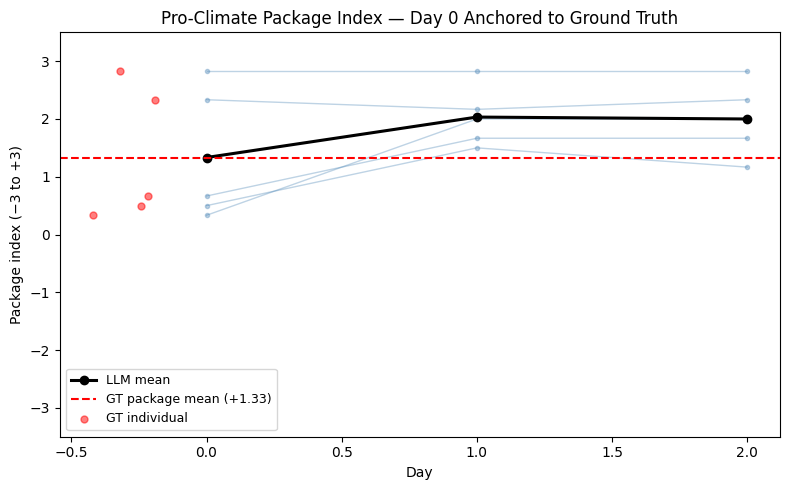

In [8]:
print(f"Mean package index by day:")
for day, val in df_package.groupby("day")["package_index"].mean().items():
    print(f"  Day {int(day)}: {val:+.2f}")
gt_pkg_mean = gt_package_df["ground_truth"].mean()
print(f"Ground truth package mean: {gt_pkg_mean:+.2f}")

fig, ax = plt.subplots(figsize=(8, 5))

# Per-agent trajectories
for aid, sub in df_package.groupby("agent_id"):
    sub = sub.sort_values("day")
    ax.plot(sub["day"], sub["package_index"], alpha=0.35, color="steelblue", linewidth=1.0,
            marker="o", markersize=3)

# LLM mean
llm_mean = df_package.groupby("day")["package_index"].mean()
ax.plot(llm_mean.index, llm_mean.values, color="black", linewidth=2.2, marker="o", label="LLM mean")

# GT mean
ax.axhline(gt_pkg_mean, color="red", linestyle="--", linewidth=1.5,
           label=f"GT package mean ({gt_pkg_mean:+.2f})")

# Individual GT values jittered
gt_vals = gt_package_df["ground_truth"].values
jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(gt_vals))
ax.scatter(np.full(len(gt_vals), -0.3) + jitter, gt_vals,
           color="red", alpha=0.5, s=25, zorder=5, label="GT individual")

ax.set_xlabel("Day")
ax.set_ylabel("Package index (−3 to +3)")
ax.set_ylim(-3.5, 3.5)
ax.set_title("Pro-Climate Package Index — Day 0 Anchored to Ground Truth")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 7. Per-Policy Trajectories (sanity)

With 2 days and 5 agents this is small, but lets us see whether any individual policy moved off the GT anchor on Day 1.



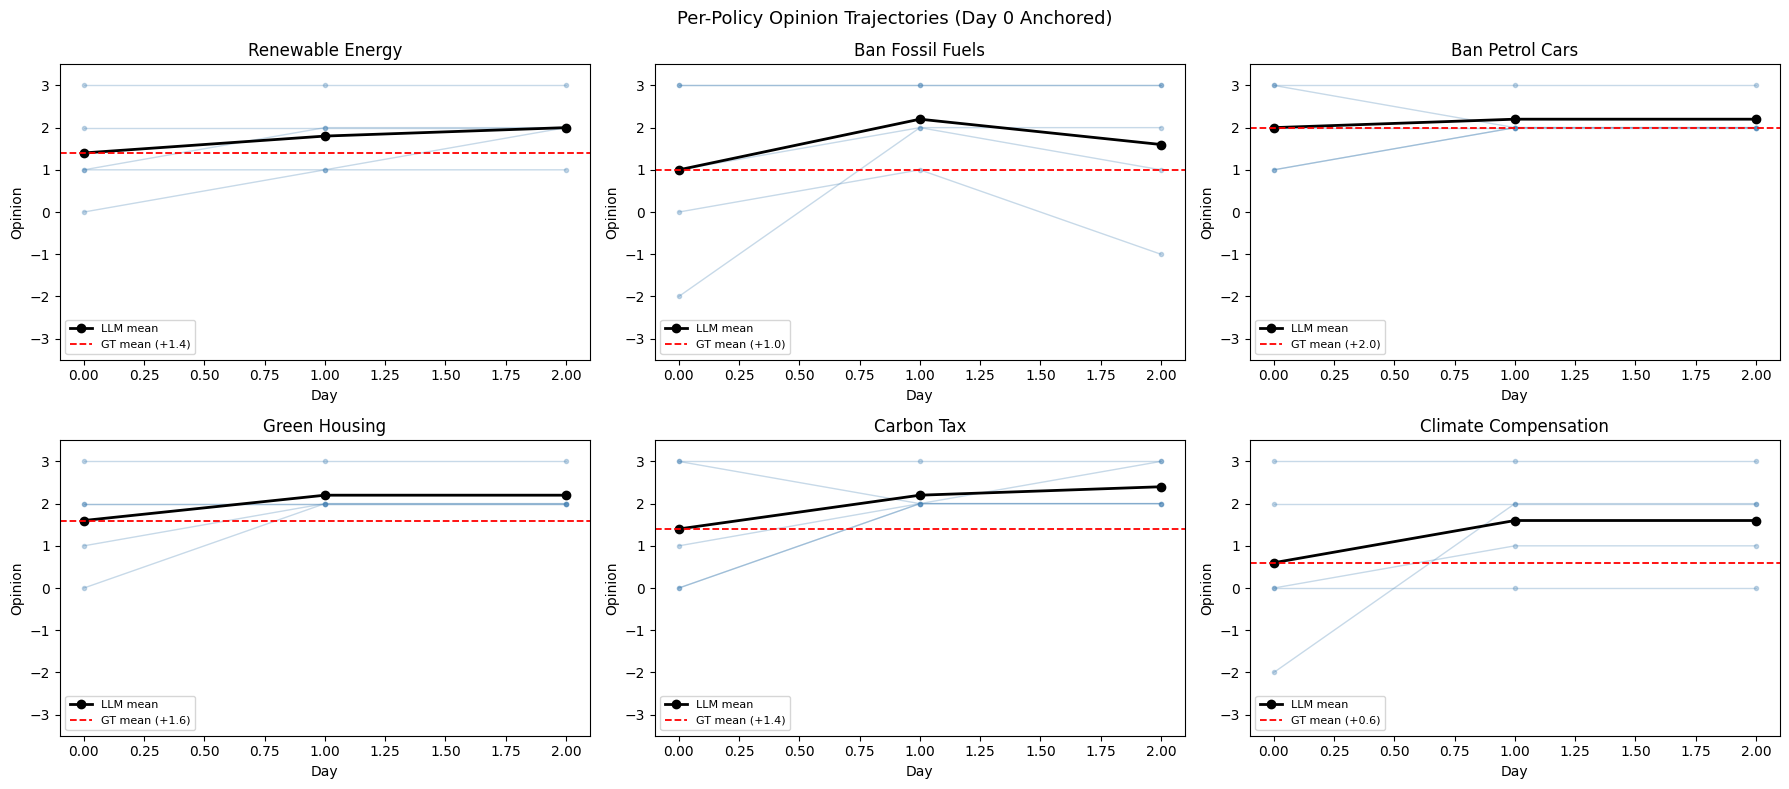

In [10]:
POLICY_SHORT_NAMES = {
    str(ClimatePolicyID.RENEWABLE_ENERGY): "Renewable Energy",
    str(ClimatePolicyID.BAN_FOSSIL_FUEL): "Ban Fossil Fuels",
    str(ClimatePolicyID.BAN_PETROL_CARS): "Ban Petrol Cars",
    str(ClimatePolicyID.GREEN_HOUSING): "Green Housing",
    str(ClimatePolicyID.CARBON_TAX): "Carbon Tax",
    str(ClimatePolicyID.CLIMATE_COMPENSATION): "Climate Compensation",
}

policies_in_sim = sorted(df_traj["policy_id"].unique())
ncols = 3
nrows = (len(policies_in_sim) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

for i, pid in enumerate(policies_in_sim):
    ax = axes[i // ncols, i % ncols]
    pdf = df_traj[df_traj["policy_id"] == pid]

    for aid, sub in pdf.groupby("agent_id"):
        sub = sub.sort_values("day")
        ax.plot(sub["day"], sub["numeric"], alpha=0.3, color="steelblue", linewidth=1.0,
                marker="o", markersize=3)

    llm_mean = pdf.groupby("day")["numeric"].mean()
    ax.plot(llm_mean.index, llm_mean.values, color="black", linewidth=2, marker="o", label="LLM mean")

    gt_p = gt_df[gt_df["policy_id"].astype(str) == str(pid)]
    if not gt_p.empty:
        gt_mean = gt_p["ground_truth"].mean()
        ax.axhline(gt_mean, color="red", linestyle="--", linewidth=1.3,
                   label=f"GT mean ({gt_mean:+.1f})")

    ax.set_xlabel("Day")
    ax.set_ylabel("Opinion")
    ax.set_ylim(-3.5, 3.5)
    ax.set_title(POLICY_SHORT_NAMES.get(str(pid), str(pid))[:40])
    ax.legend(fontsize=8)

for j in range(len(policies_in_sim), nrows * ncols):
    axes[j // ncols, j % ncols].set_visible(False)

fig.suptitle("Per-Policy Opinion Trajectories (Day 0 Anchored)", fontsize=13)
plt.tight_layout()
plt.show()


## 8. Reflections, Peer-Messaging Activity, Debias Reasoning

Three sub-checks:

(a) **Reflections per phase** — counts of Phase A/B/C reflections. Phase C count of 0 with N=5 is expected per Section 2.

(b) **Sample one reflection per phase** that did fire.

(c) **One Day≥1 debias reasoning entry** — confirms that the Step-1 anti-sycophancy reasoning is captured for end-of-day surveys.



In [11]:
# (a) Reflection counts per phase
print("Reflections per phase:")
print(df_ref.groupby("phase").size().to_string())
print(f"\nMessages logged: {len(df_messages)} "
      f"(0 expected at N=5 due to network density — see Section 2)")

# (b) Sample one reflection per phase
print("\n--- Sample reflection per phase ---")
for phase, grp in df_ref.groupby("phase"):
    if grp.empty:
        continue
    row = grp.iloc[0]
    text = row.get("reflection") or row.get("text") or ""
    print(f"\n[{phase}] agent={row['agent_id']} day={row['day']}")
    print(text[:400])

# (c) Sample one Day>=1 debias survey reasoning entry
print("\n--- Sample Day>=1 debias reasoning ---")
late = df_reasoning[df_reasoning["day"] > 0]
if late.empty:
    print("(no Day>=1 reasoning rows)")
else:
    row = late.iloc[0]
    print(f"agent={row['agent_id']} day={row['day']} policy={row['policy_id']}")
    print(row["reasoning"][:500])


Reflections per phase:
phase
C       6
P-A    10
P-B     4

Messages logged: 22 (0 expected at N=5 due to network density — see Section 2)

--- Sample reflection per phase ---

[C] agent=1923.0 day=1
Hearing these peers pushes me a bit more toward trusting the package’s coherence — they echo my sense that the measures work together (renewables, licences ban, EV cutoff, green homes, carbon pricing) and that returns-to-public or compensation elements can make the transition fairer. Their emphasis on safeguards — strong nature protections and local consent for renewables, just‑transition support 

[P-A] agent=1923.0 day=1
- Accelerate roll-out of renewable energy production (more offshore and onshore wind parks, community solar): Slightly support. I like the move toward cleaner power and public-ownership framing, and it fits with wanting to protect nature. But I worry about large-scale infrastructure impacts on local ecosystems and landscapes and prefer projects that genuinely involve and

## 9. Save Results + Cost / Time Summary

Persists outputs and writes `timings.csv` next to the run directory. The printed table at the bottom is the diagnostic that tells us which block to optimise first before scaling up to 50×7.



INFO Results saved to ../data/output/experiments/20260423_223001
INFO Plot saved to ../data/output/experiments/20260423_223001/opinion_trajectories.png
INFO Plot saved to ../data/output/experiments/20260423_223001/opinion_shares.png
INFO Plot saved to ../data/output/experiments/20260423_223001/package_index_trajectories.png
INFO Plot saved to ../data/output/experiments/20260423_223001/package_index_shares.png



Results: ../data/output/experiments/20260423_223001
Plots:   4 files

=== Wall-time summary (703.4s total = 11.7 min) ===
                    section    seconds
               build_nation   0.033028
create_network (diagnostic)   0.003157
       collect_ground_truth   0.002164
     run_simulation (TOTAL) 703.318018

Timings written to ../data/output/experiments/20260423_223001/timings.csv


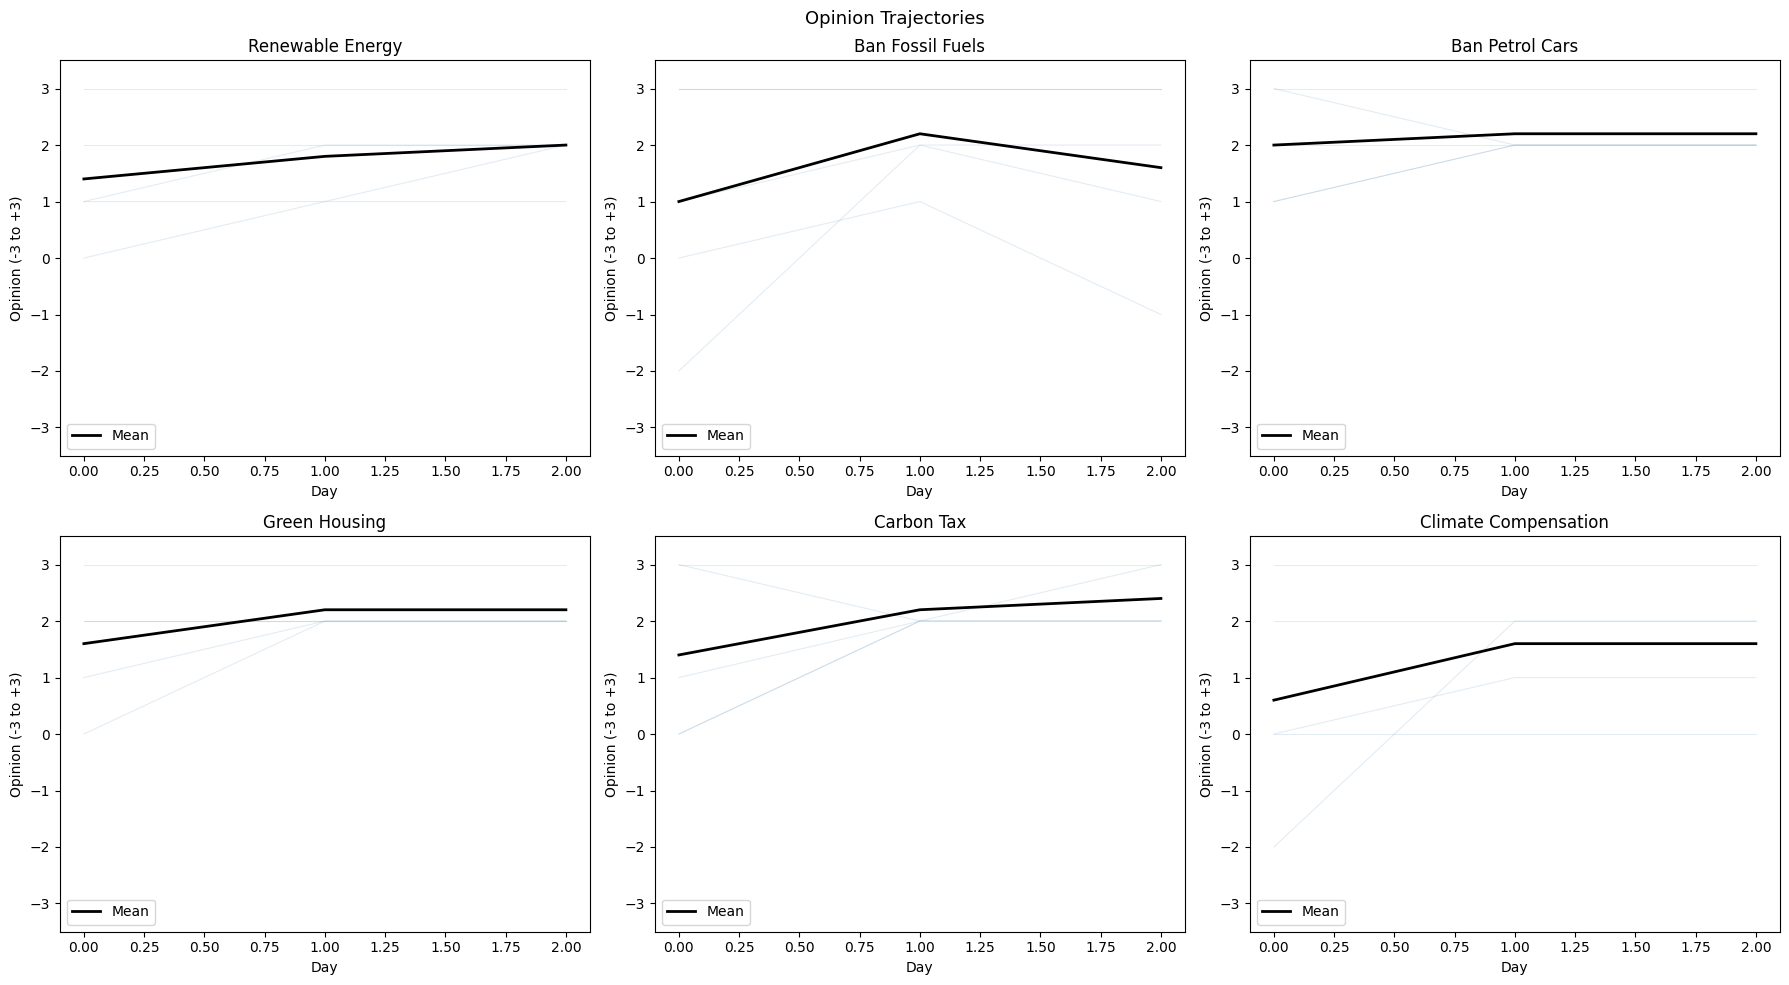

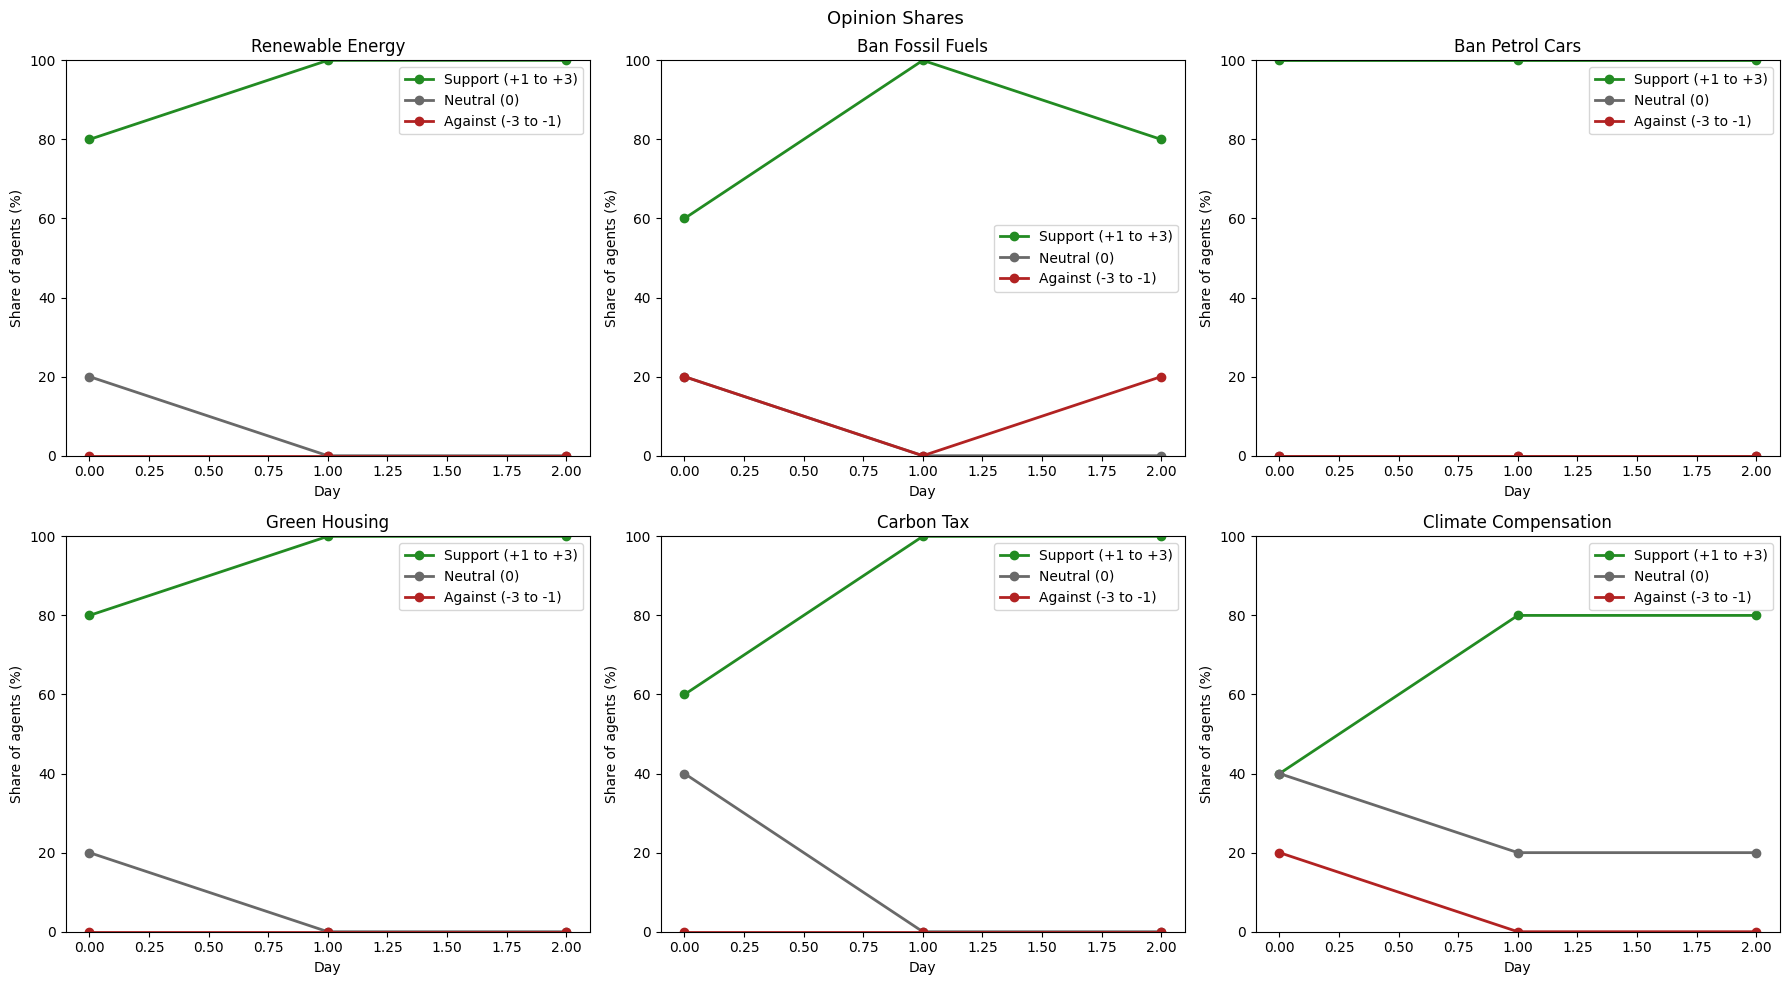

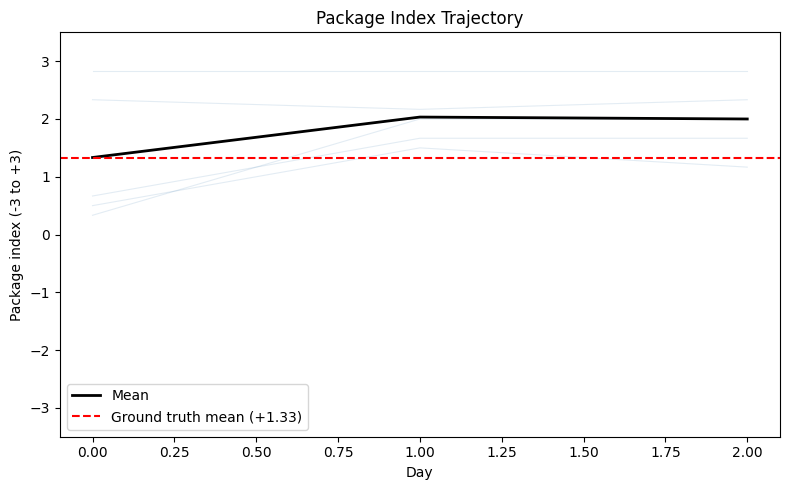

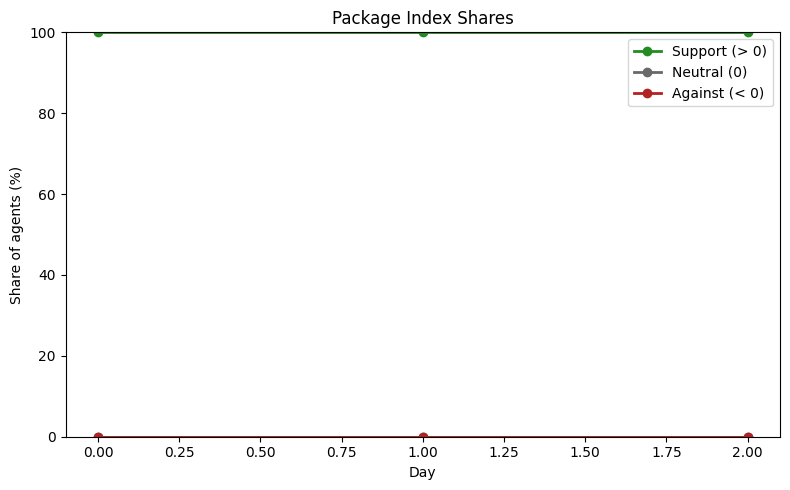

In [12]:
out_path = save_results(results, output_dir="../data/output/experiments")
plot_paths = save_result_plots(results, out_path)

# Write timings alongside results
timings_df = pd.DataFrame(TIMINGS, columns=["section", "seconds"])
total = timings_df["seconds"].sum()
timings_df.to_csv(out_path / "timings.csv", index=False)

print(f"\nResults: {out_path}")
print(f"Plots:   {len(plot_paths)} files")
print(f"\n=== Wall-time summary ({total:.1f}s total = {total/60:.1f} min) ===")
print(timings_df.to_string(index=False))
print(f"\nTimings written to {out_path / 'timings.csv'}")
